# 1.2 · LGD training

*1. Experiment 1 · notebook 1.2 of the story.* ← [1.1 · PD training](<1.1_pd_training.ipynb>) · [1.3 · PD results](<1.3_pd_results.ipynb>) →

**Experiment 1 asks: which prior?** A nano-scale TabICL model is trained **from scratch** on each
prior for 12,500 steps of 64 tasks — the same compute for every arm, which is the basis of the
comparison (`papers/2026/02_Qu_TabICLv2` §4.1). Three levers are crossed: the **credit fraction**
(the share of each batch drawn from our prior: 0 — the control, exactly TabICL's own prior — 0.5
or 1), the **filter mode** (`off`, `tabicl`, `banded`) and the **intensity** of our prior
(the boundary-mass range, mild [0.02, 0.30] or aggressive [0.15, 0.60]). That makes 15 priors, each trained with 3 seeds: 45 arms, all of which finished.

**What this notebook is — and is not.** While it trains, every arm is scored every 625 steps
(40,000 tasks) on the development split of the real datasets: 512 context rows, up to 2,000 scored.
That monitoring shows how training went; it does not decide. The decision is the benchmark in
[1.4 · LGD results](<1.4_lgd_results.ipynb>), where the prior is chosen on the development datasets and reported on the untouched
holdout (`docs/EXPERIMENTAL_DESIGN.md` §5).

**Three rules decide what every curve averages.** Only **finished** arms enter an average (an
unfinished arm stopping mid-curve would make it jump); only **development** datasets that every arm
scored enter it (the holdout is never averaged); and a group's curve is drawn only over the steps
**all** its arms logged (A2 explains why some logs start late).

**The order.** **A** — is the run sound: which arms exist and finished, what each was scored on,
what each cost, whether each learned. **B** — what the development monitoring says about each lever.
**C** — whether it holds on every dataset, outside credit and on every metric. **D** — every arm on
its own.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, pathlib
ROOT = pathlib.Path.cwd()
# Walk up to the repository root — the notebook may be opened from its chapter folder, from
# notebooks/, or from the root — then work FROM the root, so relative paths (config/...) resolve
# exactly as under `python -m src.utils.run_notebooks`.
while not (ROOT / "src" / "visualize").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from src.visualize import training_plots, figures, style, literature

style.apply()
pd.set_option("display.width", 200, "display.max_columns", 40)

TASK = "lgd"
EXP = "exp1"
# Reads output/manifests/ and output/results/ — whatever the runs have written so far, so a
# partial sweep still renders. Constructing the saver clears THIS notebook's figure folder only.
FIGS = figures.FigureSaver("1.2_lgd_training")

## A · Is the run sound?

Before any number is read: which arms exist and finished, what each was scored on, what each cost,
and whether each one learned.

### A1 · Which arms exist, and how did each finish?

**What it shows.** Every scheduled arm in one grid: one row per configuration, grouped by credit fraction, one column per seed. A number is the arm's final development R² — the mean over `base_model`; a grey cell has no development score.

**Why it matters.** A reader has to know which arms exist, which finished, and whether a block of rows or one seed stands out, before any comparison means anything: an effect shared by one seed moves every comparison that is not averaged over seeds.

**What it says.** All 45 arms finished all 12,500 steps. Only the seed-1 column carries scores: in every seed-0 and seed-2 arm, one of the 381 rows the monitor scores on `base_model` gets a non-finite prediction, which leaves R² undefined (`docs/RUNS.md`, 24-09-2026). Among the scored arms the cf = 0.5 block is clearly the highest (0.15–0.22); the control ranges from −0.09 to 0.08.

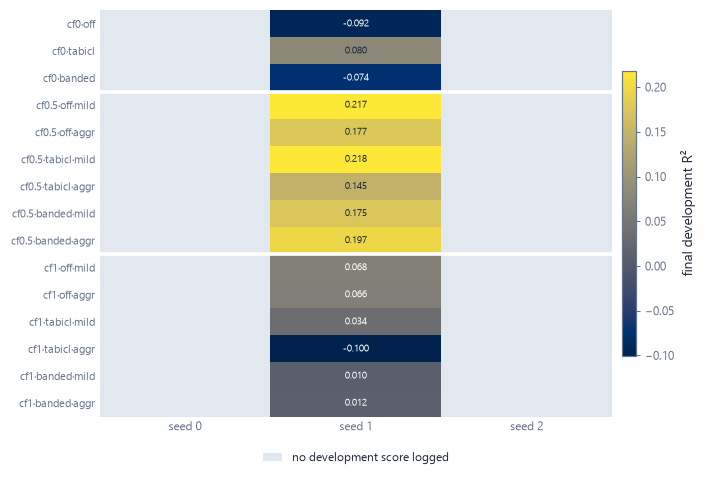

In [2]:
FIGS.save(training_plots.sweep_map(TASK, exp=EXP), "sweep_map",
    caption="Final development R² of every scheduled LGD arm as a heatmap, one row per configuration grouped by credit fraction and one column per seed; grey cells have no development score.");

### A2 · What was each arm scored on?

**What it shows.** One row per real dataset (development first, then holdout), one column per arm in the sweep map's order. A cell's colour says what that arm's score on that dataset may do: enter a development mean, exist without being averaged (not every arm carries it), be a holdout score (never averaged), or be a monitor that logged only missing values.

**Why it matters.** Arms were monitored under two protocols. Before 23-09-2026 the monitor scored "the four smallest" real datasets whatever their role, holdout ones included; since then, development datasets only. Averaging a holdout score into "which prior is best" would select on the test set, so this map fixes exactly which cells every curve in Part B is built from.

**What it says.** Every development number in this notebook rests on ONE dataset, `base_model`, and on the 15 seed-1 arms; the other arms logged only missing values there. `heloc` and `lgd_lendingclub` were never monitored: all 45 arms predate the protocol change, and their monitor scored the holdout datasets `axa`, `base_modelisation` and `loss2` instead.

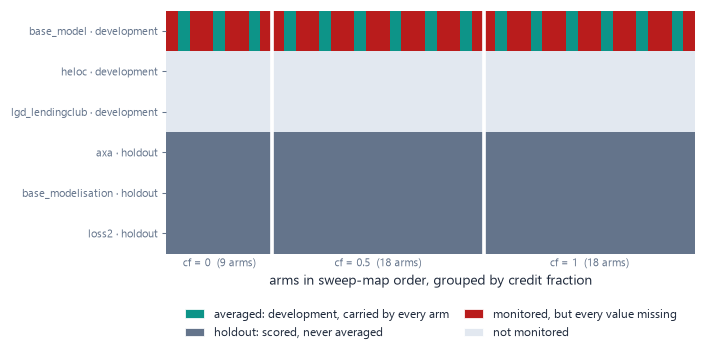

In [3]:
FIGS.save(training_plots.monitoring_coverage(TASK, exp=EXP), "monitoring_coverage",
    caption="Monitoring coverage of every LGD arm: one row per real dataset labelled development or holdout, one column per arm grouped by credit fraction, each cell coloured by whether its score enters the development mean, is not carried by every arm, is holdout, holds only missing values or was not monitored.");

### A3 · What did each arm cost?

**What it shows.** Each arm's training speed — its median steps per second over the run — grouped by filter mode, and the hours the full run takes at that speed; the bar is the group median, points are coloured and shaped by credit fraction.

**Why it matters.** TabICL generates its training tasks on the CPU while the GPU trains. A filter that throws most generated tasks away makes every batch cost several generations — a cost in walltime and VSC credits that never shows in the loss.

**What it says.** `off` and `tabicl` arms train at about 0.64–0.65 steps per second, about 5 hours. `banded` arms run at a median of 0.15 — about 23 hours — and slow down as the credit fraction and intensity rise: cf = 1 aggressive runs at 0.05 steps per second (about 65 hours), and the slowest arm, cf0.5·banded·aggr·s2, at 0.03 (about 128 hours, more than one 72-hour walltime). Three seed-2 aggressive arms outside `banded` ran at half speed (about 0.30); the telemetry does not record the node, so the cause is not visible here. GPU utilisation reads 87–95 % everywhere.

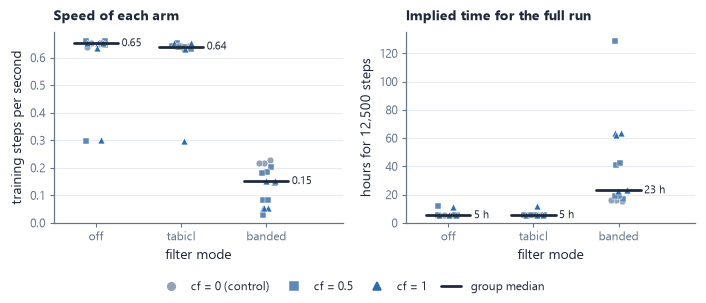

In [4]:
FIGS.save(training_plots.throughput(TASK, exp=EXP), "throughput",
    caption="Training speed per LGD arm in steps per second (left) and the implied hours for the full run (right), grouped by filter mode; points are arms coloured and shaped by credit fraction and bars are group medians with their value.");

### A4 · Did every arm learn?

**What it shows.** The training loss of every arm against the step — the pinball loss over 999 quantiles on the arm's own synthetic batch, as a rolling mean over three logged points (each logged value is one batch's loss) — with the median of the finished arms of each credit fraction drawn bold.

**Why it matters.** The loss is the one quantity every arm optimises directly, so divergence or a stall shows here first; TabICLv2's ablations warn that a prior can make training diverge (`papers/2026/02_Qu_TabICLv2` §4.4). But it is computed on each arm's own prior, so its level says which prior an arm trains on — not how well it learned.

**What it says.** No arm diverges; the medians fall over the first 2,000 steps and slowly after. The levels separate by prior — final medians of about 0.09 (cf = 0), 0.06 (cf = 0.5) and 0.03 (cf = 1) — consistent with the third to half of each credit task's rows that sit exactly on an atom. A level is never compared across fractions.

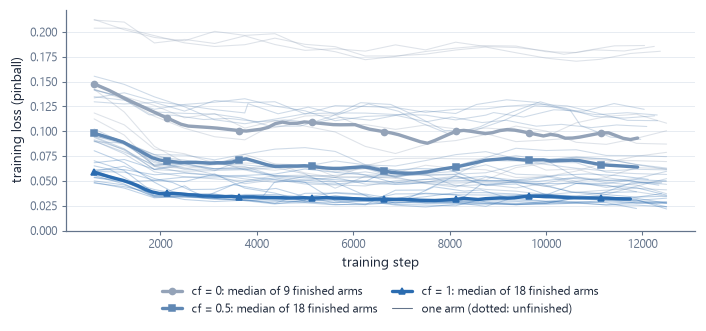

In [5]:
FIGS.save(training_plots.training_loss(TASK, exp=EXP), "training_loss",
    caption="Training loss against optimisation step for every LGD arm, a rolling mean over three logged batches coloured by credit fraction, with the median of each credit fraction bold.");

### A5 · Is every part of the network learning?

**What it shows.** Left, each block's gradient norm; right, the gradient divided by the block's weight norm — how far one step moves the block relative to its size. Both are averaged over all arms, on logarithmic axes. The telemetry records the column encoder, the row encoder and the ICL blocks; the prediction head is not logged.

**Why it matters.** A block whose gradient sits orders of magnitude below the others is effectively frozen, and the loss cannot say which one.

**What it says.** All three blocks keep learning: the gradient-to-weight ratios settle between about 3 × 10⁻⁴ and 1 × 10⁻³ and none collapses. The row encoder's gradient falls fastest early (from about 0.4 to about 0.03 by step 2,000) and the ICL blocks' ratio drifts lowest by the end, all within a factor of four of each other.

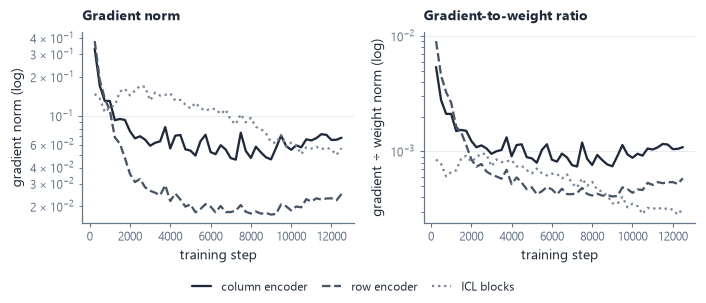

In [6]:
FIGS.save(training_plots.gradient_health(TASK, exp=EXP), "gradient_health",
    caption="Mean per-block gradient L2 norm (left) and ratio of gradient norm to weight norm (right) against training step on logarithmic axes, one line per architecture block (column encoder, row encoder, ICL blocks), averaged over all arms.");

## B · What does the development monitoring say?

The development R² over training and at its end, lever by lever. It guides the eye; the benchmark in
[1.4 · LGD results](<1.4_lgd_results.ipynb>) decides.

### B1 · Development R² over training

**What it shows.** The development R² of every arm against the step, averaged over `base_model`, in its credit-fraction colour, with the mean of each fraction drawn bold.

**Why it matters.** The first look at how models trained on each prior do on real credit data they never trained on — and whether the fractions separate early, late or not at all.

**What it says.** cf = 0.5 pulls ahead from about step 3,000 and ends near 0.19; cf = 1 and the control stay near zero (about 0.02 and −0.03). Single arms swing widely early on — down to −0.6 — so one curve on its own means little.

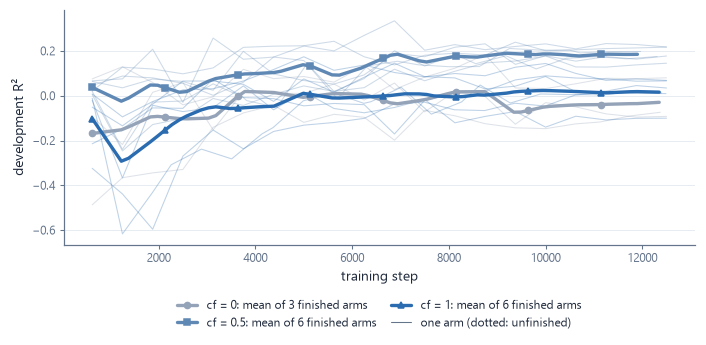

In [7]:
FIGS.save(training_plots.metric_over_training(TASK, exp=EXP), "metric_over_training",
    caption="Development R² averaged over the development datasets every arm scored, against training step; one line per arm coloured by credit fraction, with the mean of each credit fraction bold.");

### B2 · Credit prior versus the control

**What it shows.** Credit-prior arms (any credit fraction above 0) against the control arms (credit fraction 0 — TabICL's own prior): the median over the finished arms of each group, with the inter-quartile band.

**Why it matters.** The experiment's comparison, as a curve. A gap narrower than the bands is not read as an effect.

**What it says.** The credit median climbs to about 0.11; the control's ends near −0.09. The bands overlap until about step 6,000 and separate after. With 12 credit and 3 control arms, one development dataset and one seed, this is a strong hint, not yet a result.

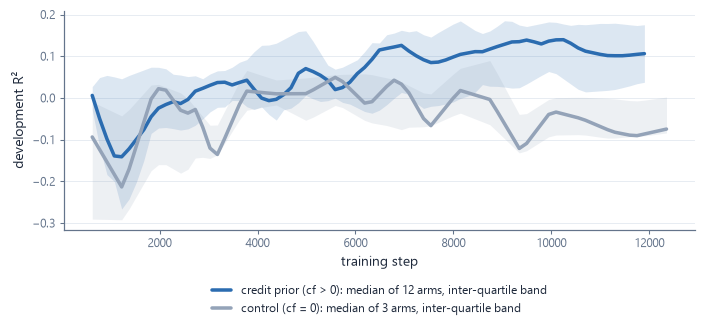

In [8]:
FIGS.save(training_plots.credit_vs_control_over_training(TASK, exp=EXP), "credit_vs_control_over_training",
    caption="Development R² against training step for credit-prior arms and control arms: median lines with shaded inter-quartile bands over the finished arms of each group.");

### B3 · Which lever moves the score?

**What it shows.** One panel per swept lever (credit fraction, filter mode and intensity), one mean curve per value over the finished arms that share it, all panels on one y axis.

**Why it matters.** The size of each lever's effect, side by side: a lever whose curves lie on top of each other does nothing, whatever the others do.

**What it says.** The credit fraction dominates: cf = 0.5 ends about 0.17 above cf = 1 and 0.22 above the control. The filter modes end at the same level, `banded` after a deep early dip; the mild intensity ends slightly above the aggressive one (about 0.12 against 0.08).

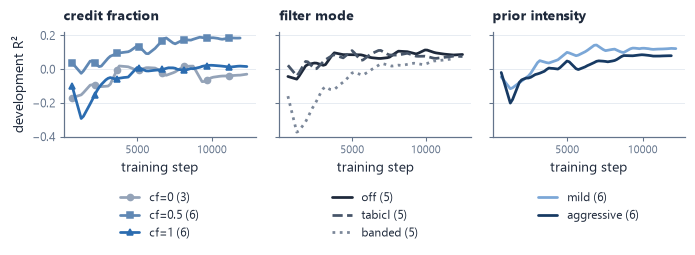

In [9]:
FIGS.save(training_plots.metric_by_levers(TASK, exp=EXP), "metric_by_levers",
    caption="Development R² against training step, one panel per swept lever with one mean line per lever value over the finished arms sharing it, all panels on a shared vertical axis.");

### B4 · Final score, lever by lever

**What it shows.** Every finished arm's final development score, grouped by each lever in turn: points coloured and shaped by credit fraction, a bar at each group mean, one shared y axis.

**Why it matters.** Final scores as a screen, one lever at a time. The sweep is factorial, so a lever's groups can differ merely because they contain different credit fractions; B5 separates the two.

**What it says.** Every cf = 0.5 arm scores between 0.14 and 0.22; cf = 1 arms between −0.10 and 0.07; control arms between −0.09 and 0.08. The filter and intensity groups differ by less than the spread inside them.

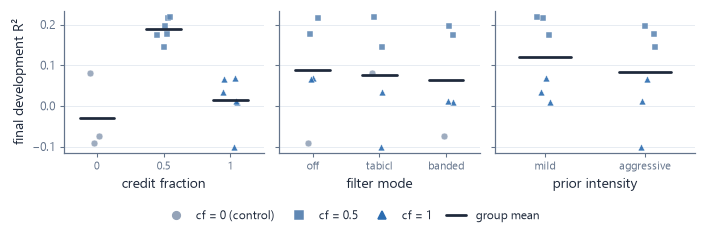

In [10]:
FIGS.save(training_plots.final_metric_by_lever(TASK, exp=EXP), "final_metric_by_lever",
    caption="Final development R² of every finished arm as points coloured and shaped by credit fraction, one panel per swept lever, with a horizontal bar at each group mean.");

### B5 · Each lever within each credit fraction

**What it shows.** Each lever other than the credit fraction, drawn within each fraction: points are finished arms, lines join the per-value means, whiskers are ±1 standard deviation over seeds. A lever the control does not have appears as the control's band (its mean ± 1 SD) instead.

**Why it matters.** Pooling a lever over fractions mixes the fraction's larger effect into it; within one fraction, a real effect of the other levers has nowhere to hide.

**What it says.** With one scored seed per configuration the whiskers are empty and each point is a single arm. cf = 0.5 stays at 0.17–0.20 whatever the filter or intensity; cf = 1 moves between −0.03 and 0.07 and the control between −0.09 and 0.08 — differences between single runs, not effects.

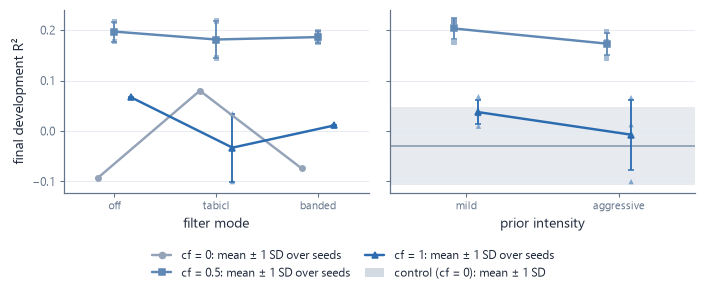

In [11]:
FIGS.save(training_plots.lever_interaction(TASK, exp=EXP), "lever_interaction",
    caption="Final development R² against each lever other than credit fraction, one series per credit fraction: points are finished arms, lines join the per-value means, whiskers show one standard deviation over seeds, and the grey band is the control mean plus or minus one standard deviation.");

### B6 · Effect against seed noise

**What it shows.** Every configuration's seeds on one axis, best configuration at the top: points are seeds, the line their range, the tick their mean; the dashed line is the control's mean.

**Why it matters.** A difference between two configurations is only worth reading where it clearly exceeds the spread between one configuration's own seeds — the reason Experiment 1 runs three.

**What it says.** Only seed 1 has a score (A1), so each row is one arm and no seed spread can be read: this is a ranking of 15 single runs. The six cf = 0.5 configurations take the top six places.

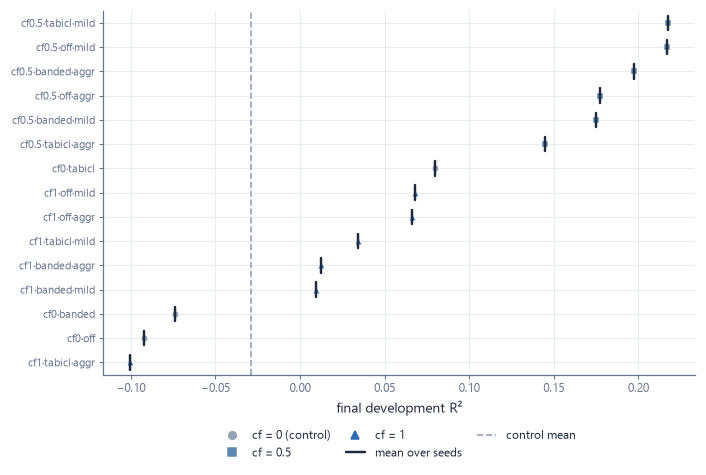

In [12]:
FIGS.save(training_plots.seed_spread(TASK, exp=EXP), "seed_spread",
    caption="Final development R² of every configuration's seeds as points on one horizontal axis, configurations sorted by their mean with the range and mean marked per row; the dashed line is the control mean.");

## C · Where does it hold?

A mean can be carried by one easy dataset, and a gain on credit can be bought with general ability.
These figures check both, and every metric the monitor records.

### C1 · Every monitored dataset

**What it shows.** One panel per real dataset the monitor scored, development first: the mean over the finished credit-prior arms and over the finished control arms that scored it. Each title gives the dataset's side of the split and how many finished arms scored it.

**Why it matters.** Development panels are what the means above are built from. Holdout panels are shown as the evidence they are and never enter a mean — they belong to the benchmark.

**What it says.** The credit arms lead on all four datasets: on `base_model` — the development mean — by about 0.14 at the end, and on the three holdout datasets by about 0.15 (`axa`), 0.20 (`loss2`) and 0.05 (`base_modelisation`). Agreement on the holdout is encouraging, but it is exactly what the benchmark (1.4) has to confirm.

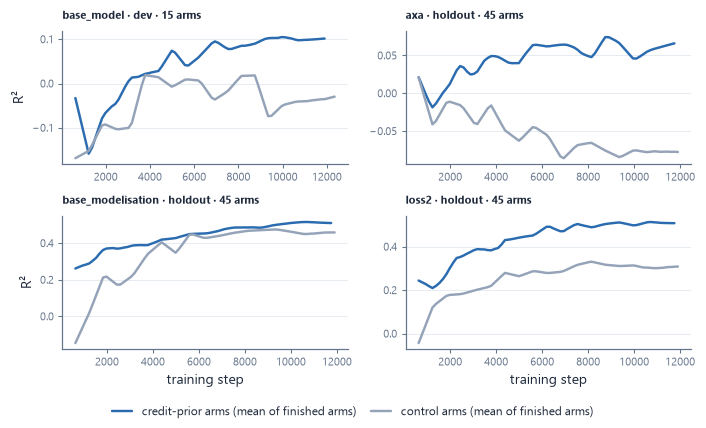

In [13]:
for _p in range(1, training_plots.per_dataset_pages(TASK, exp=EXP) + 1):
    FIGS.save(training_plots.per_dataset_curves(TASK, _p, exp=EXP), f"per_dataset_p{_p}",
        caption="Monitored R² against training step, one panel per real dataset labelled with its side of the split and the number of finished arms that scored it, credit-prior arms against control arms.");

### C2 · Credit data against out-of-domain data

**What it shows.** The development score on the real credit datasets (solid) and on eight public regression suites from outside credit (dashed), each averaged separately over credit-prior and control arms.

**Why it matters.** Out-of-domain retention is a first-class axis of the design (`docs/EXPERIMENTAL_DESIGN.md` §5.3): a prior that lifts credit scores by making the model worse everywhere else has not made it better.

**What it says.** The credit arms gain on credit data (about 0.10 against −0.03 on `base_model`) and lose out of domain (0.49 against 0.58 on the eight suites): on this monitor, specialising costs generality.

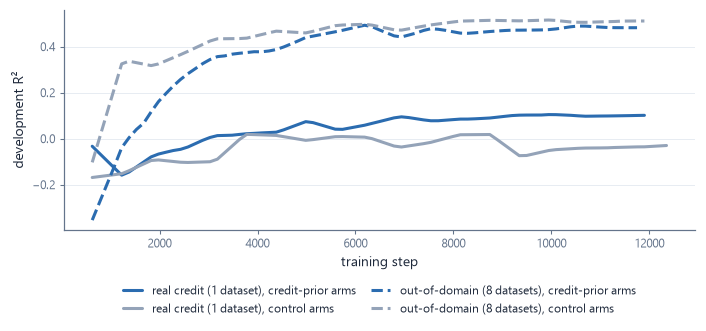

In [14]:
FIGS.save(training_plots.real_vs_ood(TASK, exp=EXP), "real_vs_ood",
    caption="Development R² on the real-credit datasets (solid) and on the out-of-domain suites (dashed) against training step, averaged separately over credit-prior and control arms.");

### C3 · Every development metric

**What it shows.** Every metric the monitor records, one figure per group (for LGD: accuracy; ranking and calibration; intervals and boundary atoms), one panel per metric: the mean over finished credit-prior and control arms. A title carries the metric's goal — ↑ higher is better, ↓ lower is better, → a value it should equal, drawn dashed; a predicted boundary share is drawn against the true share in the data.

**Why it matters.** A prior that improves ranking but hurts calibration, or fits the interior but misses the atoms, shows here and nowhere in R².

**What it says.** Accuracy: the credit arms are better on every error measure (RMSE, MAE, pinball, CRPS, Brier). Ranking: better on Spearman and Kendall. Calibration is mixed: their bias is smaller (about −0.07 against −0.19), but their calibration slope is about 0.6, below the ideal 1 — their predictions are too spread out — where the control's (about 1.25) are too timid. Intervals: both groups' 50 %, 80 % and 90 % intervals cover close to their nominal share. Atoms: neither group ever predicts an exact 0 or 1 — the predicted share at each boundary stays near zero against true shares of about 10 % and 12 % — though the credit arms' errors on boundary rows are much smaller (MAE about 0.31 against 0.45).

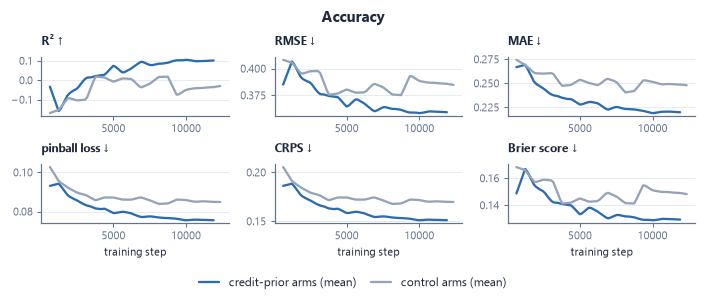

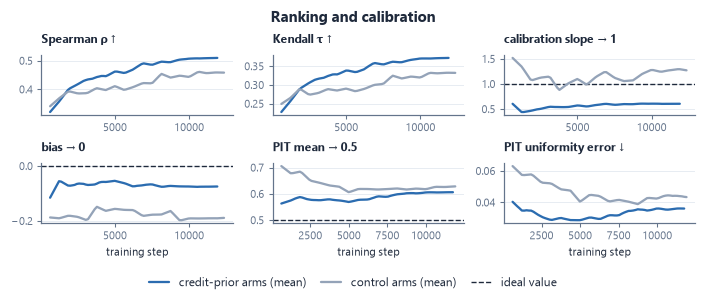

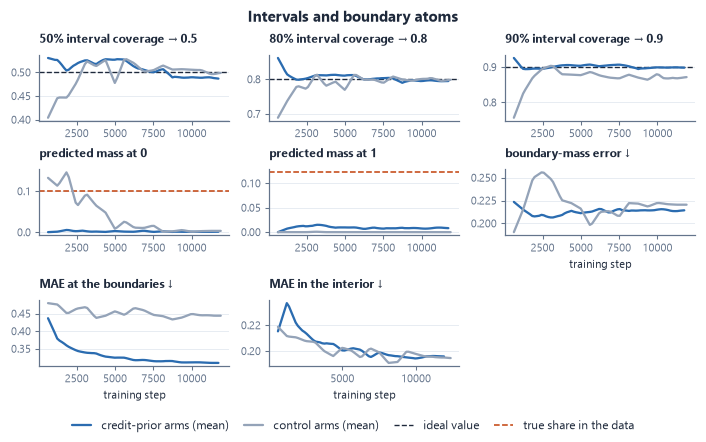

In [15]:
for _p in range(1, training_plots.metric_pages(TASK, exp=EXP) + 1):
    FIGS.save(training_plots.all_eval_metrics(TASK, _p, exp=EXP), f"eval_metrics_p{_p}",
        caption="Each logged development metric against training step, one panel per metric and one figure per metric group, credit-prior and control means over the finished arms; the title marks the improving direction or target value, drawn as a dashed line.");

## D · Every arm on its own

For the reader who wants to check one configuration rather than trust a mean.

### D1 · Every configuration, seed by seed

**What it shows.** One panel per configuration in the sweep map's order: its seeds as separate lines of the development score, all panels on shared axes.

**Why it matters.** An arm that behaved unlike its neighbours, or unlike its own other seeds, stands out here and disappears in every mean.

**What it says.** One line per panel — seed 1. Most cf = 0.5 configurations settle above 0.1 by step 5,000; the `banded` configurations start deep below zero — cf1·banded·mild and cf1·banded·aggr at about −0.6 — before recovering.

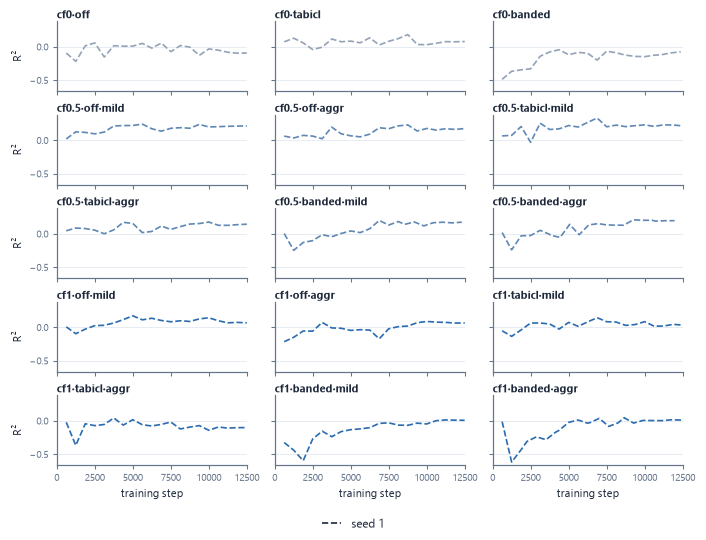

In [16]:
for _p in range(1, training_plots.config_pages(TASK, exp=EXP) + 1):
    FIGS.save(training_plots.per_config(TASK, _p, exp=EXP), f"per_config_p{_p}",
        caption="Development R² against training step, one panel per configuration in sweep-map order with one line per seed, all panels on shared axes.");

### D2 · The best arm and the worst

**What it shows.** The finished arms with the highest and the lowest final development score: training loss and development score side by side.

**Why it matters.** Did the worst arm fail to learn, or learn something that does not transfer? The loss answers the first question, the score the second.

**What it says.** The worst arm (cf1·tabicl·aggr·s1) reaches a lower training loss than the best (cf0.5·tabicl·mild·s1) and still scores −0.10 against 0.22 on `base_model`: the loss level reflects the prior, not the quality (A4).

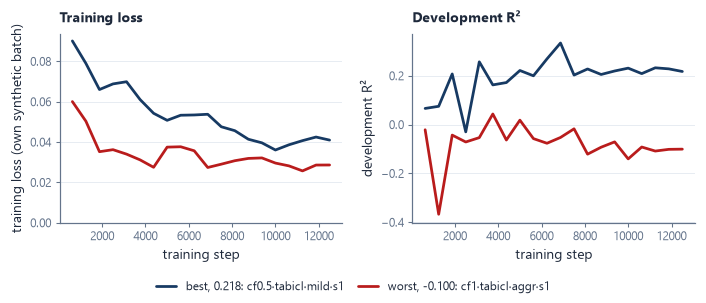

In [17]:
FIGS.save(training_plots.best_and_worst(TASK, exp=EXP), "best_and_worst",
    caption="Training loss (a rolling mean over three logged batches) and development R² against training step for the best and the worst finished arm by final development score.");

## Summary

The sweep in text: the run (A), what the development monitoring says (B) and where it holds (C). Printed last, in the order of the sections above, so `output/All_Results.md` carries the
same story as this notebook, followed by the `tfm-library` sources it cites (pin `e5ce016`) and the
list of figures.

In [18]:
print(training_plots.training_summary(TASK, exp=EXP))
print()
print(literature.references_md(["batch", "stage1_lr", "optimizer", "filter_rate_reg", "filter_pval", "filter_extratrees_n"]))
print()
print(FIGS.summary())

EXP1 LGD TRAINING — development-split monitoring

A. THE RUN
  arms: 45 scheduled | 45 started | 45 finished | 0 unfinished
  development datasets averaged (1): base_model
  holdout datasets monitored but never averaged: axa, base_modelisation, loss2
  finished arms without a development score: 30 of 45 (seed 0: 15, seed 2: 15) — a monitor that logged only missing values
  arms monitored before the development-only protocol: 45 of 45
  group curves are drawn only where all their arms have a value: finished arms' logs start at step 625-625 and end at 11,876-12,500
  median speed by filter: off 0.65 steps/s (~5 h) | tabicl 0.64 steps/s (~5 h) | banded 0.15 steps/s (~23 h)
  GPU utilisation, median per arm: 93% (range 87-95%)
  peak allocated GPU memory: 13.1-13.1 GB per arm
  final training loss by credit fraction (each on its own prior's tasks): cf 0 0.093 | cf 0.5 0.064 | cf 1 0.032

B. THE ANSWER — final development R², 15 finished arms
  by credit fraction: cf=0 -0.0289 ±0.0773 (n=3)